In [1]:
from CMGRDF import *
import ROOT

lumi = 59.80
cache = SimpleCache("/afs/cern.ch/work/g/gpetrucc/ttHH/CMGRDF/examples/run_jupyter.dir")
ROOT.EnableImplicitMT(16)
printer = PlotSetPrinter(topRightText="L = %(lumi).1f fb^{-1} (13 TeV)", 
                         #showRatio=True, 
                         maxRatioRange=(0, 2.49),
                         plotFormats="png,txt,pdf,jupyter")

Welcome to JupyROOT 6.26/08


### Study signal MC sample

Booked 1 sums and 0 targets in 0.062s
Booked 0 sums and 0 targets in 0.530s
Filled 1 sums in 0.002s
Merged 3 plots in 0.001s


Printing GenGamma_ptMax in plots/020/signalMC/H_to_GG (formats: ['png', 'txt', 'pdf', 'jupyter'])


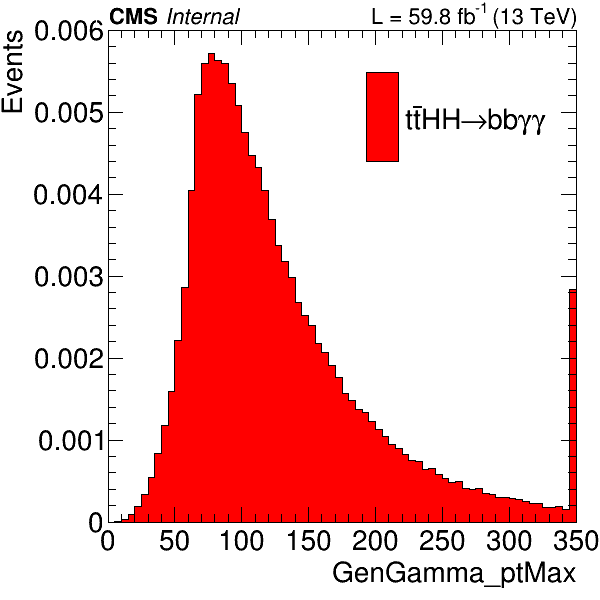

Printing GenGamma_ptMin in plots/020/signalMC/H_to_GG (formats: ['png', 'txt', 'pdf', 'jupyter'])


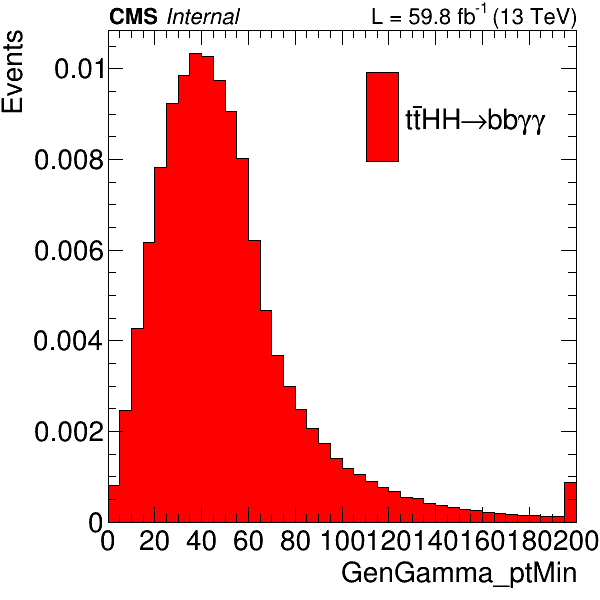

Printing GenGamma_maxAbsEta in plots/020/signalMC/H_to_GG (formats: ['png', 'txt', 'pdf', 'jupyter'])


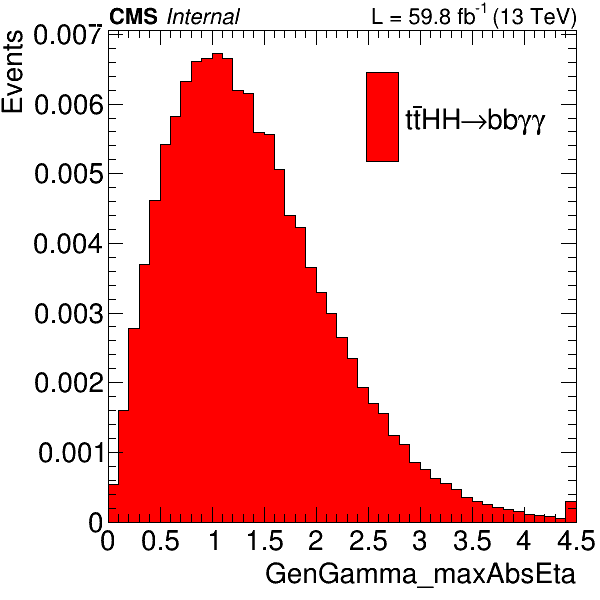

Merged 4 yields in 0.000s
   Beginning :        12.25 +-     0.00 (stat)
   GGEta     :        10.96 +-     0.00 (stat): 0.89484  0.89484
   GGPt35    :        10.91 +-     0.00 (stat): 0.99520  0.89054
   GGPt22    :         9.79 +-     0.00 (stat): 0.89737  0.79915



In [10]:
from CMGRDF.collectionUtils import DefineSkimmedCollection
eosPath = "/eos/cms/store/cmst3/group/tthlep/gpetrucc/UL18/TTHHTo2B2G_TuneCP5_13TeV-madgraph-pythia8/NanoAODv9"
procs_signal = [ 
    Process("ttHH", 
            MCSample("TTHHTo2B2G", f"{eosPath}/step7_job*.root", 
                     xsec=0.775e-3*2*0.582*2.270E-03),
            fillColor = ROOT.kRed,
            label = "t#bar{t}HH#rightarrowbb#gamma#gamma")
]
H_to_gg = Flow("H_to_GG",
    Marker("Beginning", "Just a marker for the start of the cut flow"),
    Define("GenPart_motherPdgId", "Take(GenPart_pdgId, GenPart_genPartIdxMother)"),
    Define("GenPart_isGammaFromHiggs", "abs(GenPart_pdgId) == 22 && GenPart_motherPdgId == 25"),
    DefineSkimmedCollection("GenGammaFromHiggs","GenPart",("pt","eta"),mask="GenPart_isGammaFromHiggs"),
    Cut("HtoGG", "nGenGammaFromHiggs == 2"), 
)
H_to_gg_acc = H_to_gg.clone("H_to_gg_acc").append(
    Cut("GGEta", "Max(abs(GenGammaFromHiggs_eta)) < 2.4"),
    Cut("GGPt35", "Max(GenGammaFromHiggs_pt) > 35"),
    Cut("GGPt22", "Min(GenGammaFromHiggs_pt) > 22"),
)
H_to_gg_plots = [
    Plot("GenGamma_ptMax", "Max(GenGammaFromHiggs_pt)", (70,0,350)),
    Plot("GenGamma_ptMin", "Min(GenGammaFromHiggs_pt)", (40,0,200)),
    Plot("GenGamma_maxAbsEta", "Max(abs(GenGammaFromHiggs_eta))", (45,0,4.5)),
]
maker = Processor(cache=cache)
cutFlowCuts = ["Beginning", "HToGG", "GGEta", "GGPt35", "GGPt22"]
maker.book(procs_signal, lumi, H_to_gg, H_to_gg_plots)
maker.bookCutFlow(procs_signal, lumi, H_to_gg_acc, cutNames = cutFlowCuts)
printer.printSet(maker.runPlots(), "plots/020/signalMC/{flow}")

yields = maker.runYields()
y0, yprev = None, None
for cut, (proc, y) in yields:
    y.Scale(100)
    if y0 is None:
        print("   %-10s: %12.2f +- %8.2f (stat)" % (cut.name, y.central, y.stat))
        y0 = y.central
    else:
        print("   %-10s: %12.2f +- %8.2f (stat): %7.5f  %7.5f" % (cut.name, y.central, y.stat, y.central/yprev, y.central/y0))
    yprev = y.central

print("")